In [23]:
# ============================================================
# 01 — Data Collection
# Monetary Policy Transmission: Brazil vs USA (2021–2024)
# ============================================================

import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from fredapi import Fred

# --- Paths ---
project_root  = Path.cwd()
raw_dir       = project_root / 'data' / 'raw'
processed_dir = project_root / 'data' / 'processed'
figures_dir   = project_root / 'outputs' / 'figures'

for d in [raw_dir, processed_dir, figures_dir]:
    d.mkdir(parents=True, exist_ok=True)

# --- Sample period ---
START = '2021-01-01'
END   = '2024-12-31'

# --- FRED API key (reads .env manually to avoid BOM encoding issues on Windows) ---
with open(project_root / '.env', 'r', encoding='utf-8-sig') as f:
    for line in f:
        line = line.strip()
        if line and not line.startswith('#') and '=' in line:
            key, value = line.split('=', 1)
            os.environ[key.strip()] = value.strip()

FRED_API_KEY = os.getenv('FRED_API_KEY')
if not FRED_API_KEY:
    raise EnvironmentError('FRED_API_KEY not found. Check your .env file.')

# --- Plot style ---
plt.rcParams.update({
    'figure.dpi'        : 150,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'font.size'         : 10
})

print(f'FRED_API_KEY loaded: {FRED_API_KEY[:4]}{"*" * (len(FRED_API_KEY) - 4)}')
print('Setup OK')

FRED_API_KEY loaded: ee6f****************************
Setup OK


In [24]:
# --- Célula 2: Brasil — BCB/SGS ---

def fetch_bcb(series_id: int, name: str, start: str, end: str) -> pd.Series:
    """
    Fetch a single time series from the BCB SGS REST API.
    No API key required.
    """
    url = (
        f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{series_id}/dados'
        f'?formato=json'
        f'&dataInicial={pd.Timestamp(start).strftime("%d/%m/%Y")}'
        f'&dataFinal={pd.Timestamp(end).strftime("%d/%m/%Y")}'
    )
    resp = requests.get(url, timeout=15)
    resp.raise_for_status()

    df = pd.DataFrame(resp.json())
    df['data']  = pd.to_datetime(df['data'], dayfirst=True)
    df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
    series = df.set_index('data')['valor'].rename(name)

    print(f'  SGS {series_id:>5} | {name:<12} | {len(series):>3} obs '
          f'[{series.index.min().date()} → {series.index.max().date()}]')
    return series


print('Fetching Brazilian series from BCB/SGS...\n')

selic   = fetch_bcb(432,  'selic',   START, END)  # Selic meta % a.a.
ipca    = fetch_bcb(433,  'ipca',    START, END)  # IPCA variação mensal %
brl_usd = fetch_bcb(3698, 'brl_usd', START, END)  # BRL/USD comercial venda

# Combine and resample to month-end
brazil_raw = (
    pd.concat([selic, ipca, brl_usd], axis=1)
    .resample('ME').last()
    .dropna(how='all')
    .loc[START:END]
)

brazil_raw.to_csv(raw_dir / 'brazil_raw.csv')
print(f'\nShape: {brazil_raw.shape} → saved to data/raw/brazil_raw.csv')
brazil_raw.head()

Fetching Brazilian series from BCB/SGS...

  SGS   432 | selic        | 1461 obs [2021-01-01 → 2024-12-31]
  SGS   433 | ipca         |  48 obs [2021-01-01 → 2024-12-01]
  SGS  3698 | brl_usd      |  48 obs [2021-01-01 → 2024-12-01]

Shape: (48, 3) → saved to data/raw/brazil_raw.csv


,selic,ipca,brl_usd
data,,,
2021-01-31,2.00,0.25,5.3562
2021-02-28,2.00,0.86,5.4165
2021-03-31,2.75,0.93,5.6461
2021-04-30,2.75,0.31,5.5621
2021-05-31,3.50,0.83,5.2911


In [25]:
# --- Cell 3: United States — FRED ---

def fetch_fred(client: Fred, series_id: str, name: str,
               start: str, end: str) -> pd.Series:
    """Fetch a single series from FRED."""
    s = client.get_series(series_id,
                          observation_start=start,
                          observation_end=end)
    s.name  = name
    s.index = pd.to_datetime(s.index)
    print(f'  FRED {series_id:<12} | {name:<12} | {len(s):>3} obs '
          f'[{s.index.min().date()} → {s.index.max().date()}]')
    return s


print('Fetching US series from FRED...\n')
fred = Fred(api_key=FRED_API_KEY)

fedfunds = fetch_fred(fred, 'FEDFUNDS',  'fedfunds', START, END)
cpi_idx  = fetch_fred(fred, 'CPIAUCSL',  'cpi_idx',  '2020-12-01', END)  # one month earlier
dxy      = fetch_fred(fred, 'DTWEXBGS',  'dxy',      START, END)

# CPI monthly % change — first obs (Dec 2020) used only to compute Jan 2021 change
cpi_pct      = cpi_idx.pct_change() * 100
cpi_pct.name = 'cpi'
cpi_pct      = cpi_pct.loc[START:]  # drop Dec 2020 after computing change

# Combine and resample to month-end
usa_raw = (
    pd.concat([fedfunds, cpi_pct, dxy], axis=1)
    .resample('ME').last()
    .dropna(how='all')
    .loc[START:END]
)

# Drop any remaining NaN rows
usa_raw = usa_raw.dropna()

usa_raw.to_csv(raw_dir / 'usa_raw.csv')
print(f'\nShape: {usa_raw.shape} → saved to data/raw/usa_raw.csv')
usa_raw.head()

Fetching US series from FRED...

  FRED FEDFUNDS     | fedfunds     |  48 obs [2021-01-01 → 2024-12-01]
  FRED CPIAUCSL     | cpi_idx      |  49 obs [2020-12-01 → 2024-12-01]
  FRED DTWEXBGS     | dxy          | 1043 obs [2021-01-01 → 2024-12-31]

Shape: (48, 3) → saved to data/raw/usa_raw.csv


C:\Users\Leo\AppData\Local\Temp\ipykernel_16072\3515171698.py:30: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  pd.concat([fedfunds, cpi_pct, dxy], axis=1)


,fedfunds,cpi,dxy
2021-01-31,0.09,0.244996,111.9511
2021-02-28,0.08,0.339568,112.8306
2021-03-31,0.07,0.524321,113.8234
2021-04-30,0.07,0.623865,112.0839
2021-05-31,0.06,0.663506,110.7576


In [26]:
# --- Cell 4: Transformations for VAR ---

# Brazil — levels and log-difference of exchange rate
brazil = pd.DataFrame(index=brazil_raw.index)
brazil['selic']    = brazil_raw['selic']                          # level, % p.a.
brazil['ipca']     = brazil_raw['ipca']                           # level, monthly %
brazil['dbrl_usd'] = np.log(brazil_raw['brl_usd']).diff() * 100  # log-diff × 100 ≈ monthly % change

# USA — levels and log-difference of dollar index
usa = pd.DataFrame(index=usa_raw.index)
usa['fedfunds'] = usa_raw['fedfunds']                         # level, % p.a.
usa['cpi']      = usa_raw['cpi']                              # level, monthly %
usa['ddxy']     = np.log(usa_raw['dxy']).diff() * 100         # log-diff × 100 ≈ monthly % change

# Drop first row (NaN from diff)
brazil = brazil.dropna()
usa    = usa.dropna()

brazil.to_csv(processed_dir / 'brazil_processed.csv')
usa.to_csv(processed_dir    / 'usa_processed.csv')

print(f'Brazil processed: {brazil.shape} → saved to data/processed/brazil_processed.csv')
print(f'USA processed:    {usa.shape}    → saved to data/processed/usa_processed.csv')

Brazil processed: (47, 3) → saved to data/processed/brazil_processed.csv
USA processed:    (47, 3)    → saved to data/processed/usa_processed.csv


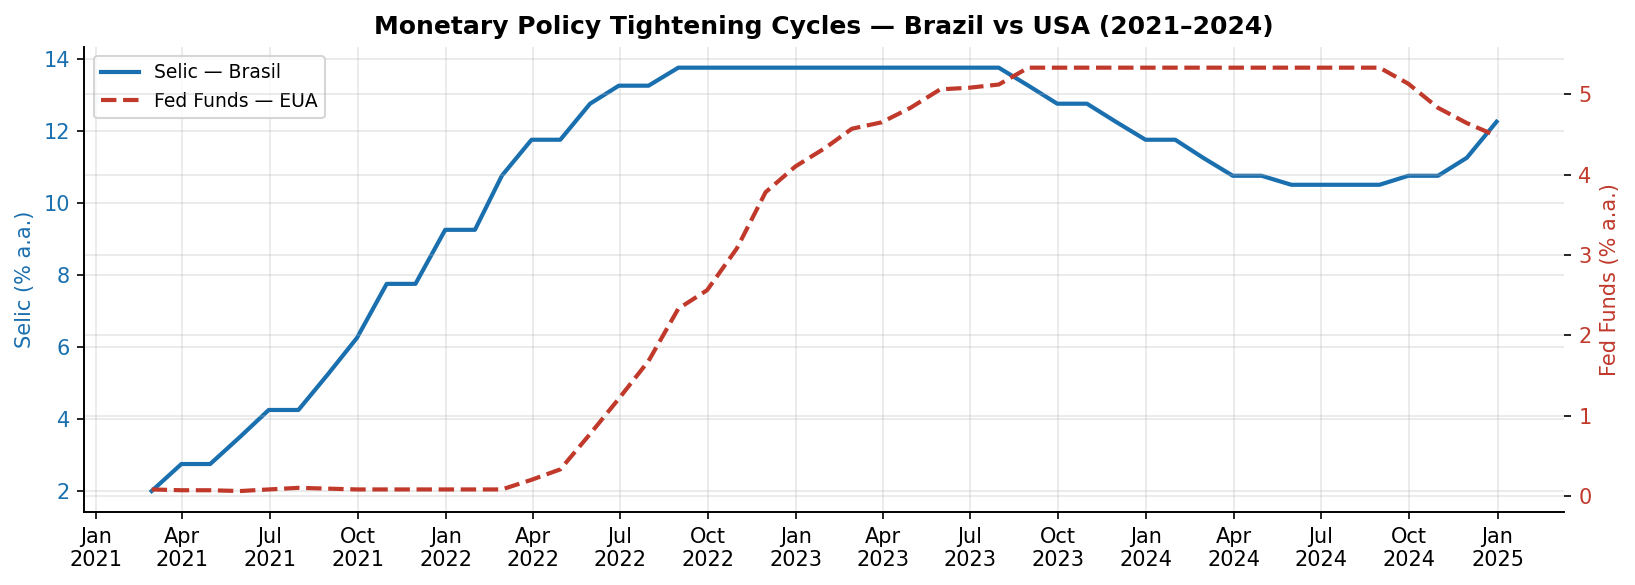

In [27]:
# --- Cell 5: Policy rate comparison chart — dual axis (different scales) ---

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(brazil.index, brazil['selic'],
        color='#1a6faf', linewidth=2, label='Selic — Brasil')
ax2 = ax.twinx()
ax2.plot(usa.index, usa['fedfunds'],
         color='#c0392b', linewidth=2, linestyle='--', label='Fed Funds — EUA')

ax.set_ylabel('Selic (% a.a.)',       color='#1a6faf', fontsize=10)
ax2.set_ylabel('Fed Funds (% a.a.)',  color='#c0392b', fontsize=10)
ax.tick_params(axis='y', labelcolor='#1a6faf')
ax2.tick_params(axis='y', labelcolor='#c0392b')
ax.set_title('Monetary Policy Tightening Cycles — Brazil vs USA (2021–2024)',
             fontsize=12, fontweight='bold')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

lines = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax.legend(lines, labels, loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(figures_dir / 'fig03_rates_comparison.png', bbox_inches='tight')
plt.show()

In [29]:
# --- Cell 5: Final check: observations, date range and missing values ---

print('=== Descriptive Statistics — Brazil ===')
print(brazil.describe().round(3))

print('\n=== Descriptive Statistics — USA ===')
print(usa.describe().round(3))

print('\n=== Missing Values Check ===')
print('Brazil:', brazil.isnull().sum().to_dict())
print('USA:   ', usa.isnull().sum().to_dict())

print(f'Brazil: {len(brazil)} obs  [{brazil.index.min().date()} → {brazil.index.max().date()}]')
print(f'USA:    {len(usa)} obs  [{usa.index.min().date()} → {usa.index.max().date()}]')
print('\nData collection complete. Next: 03_stationarity_tests.ipynb')

=== Descriptive Statistics — Brazil ===
        selic    ipca  dbrl_usd
count  47.000  47.000    47.000
mean   10.590   0.517     0.276
std     3.494   0.425     2.913
min     2.000  -0.680    -6.292
25%     9.875   0.270    -0.926
50%    11.750   0.530     0.351
75%    13.500   0.830     1.999
max    13.750   1.620     6.124

=== Descriptive Statistics — USA ===
       fedfunds     cpi    ddxy
count    47.000  47.000  47.000
mean      3.044   0.405   0.306
std       2.307   0.298   1.602
min       0.060  -0.042  -3.269
25%       0.095   0.194  -0.960
50%       4.330   0.340   0.245
75%       5.330   0.545   1.610
max       5.330   1.256   3.640

=== Missing Values Check ===
Brazil: {'selic': 0, 'ipca': 0, 'dbrl_usd': 0}
USA:    {'fedfunds': 0, 'cpi': 0, 'ddxy': 0}
Brazil: 47 obs  [2021-02-28 → 2024-12-31]
USA:    47 obs  [2021-02-28 → 2024-12-31]

Data collection complete. Next: 03_stationarity_tests.ipynb
